In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib


In [4]:
from google.colab import files
uploaded=files.upload()


Saving Cardekho_Dataset.csv to Cardekho_Dataset.csv


In [6]:
import pandas as pd
df=pd.read_csv('Cardekho_Dataset.csv')
df.head


<bound method NDFrame.head of        Unnamed: 0         car_name     brand     model  min_cost_price  \
0               0      Maruti Alto    Maruti      Alto    3.570039e+05   
1               1    Hyundai Grand   Hyundai     Grand    7.110000e+05   
2               2      Hyundai i20   Hyundai       i20    8.540829e+05   
3               3      Maruti Alto    Maruti      Alto    3.570039e+05   
4               4    Ford Ecosport      Ford  Ecosport    1.014000e+06   
...           ...              ...       ...       ...             ...   
15406       19537      Hyundai i10   Hyundai       i10    6.983200e+05   
15407       19540    Maruti Ertiga    Maruti    Ertiga    9.267760e+05   
15408       19541      Skoda Rapid     Skoda     Rapid    8.926327e+05   
15409       19542  Mahindra XUV500  Mahindra    XUV500    1.783000e+06   
15410       19543       Honda City     Honda      City    1.330978e+06   

       max_cost_price  vehicle_age  km_driven seller_type fuel_type  \
0        4.654015e+05            9     120000  Individual    Petrol   
1        7.480000e+05            5      20000  Individual    Petrol   
2        1.307926e+06           11      60000  Individual    Petrol   
3        4.654015e+05            9      37000  Individual    Petrol   
4        1.379000e+06            6      30000      Dealer    Diesel   
...               ...          ...        ...         ...       ...   
15406    7.293333e+05            9      10723      Dealer    Petrol   
15407    1.149968e+06            2      18000      Dealer    Petrol   
15408    1.563551e+06            6      67000      Dealer    Diesel   
15409    2.491000e+06            5    3800000      Dealer    Diesel   
15410    1.707437e+06            2      13000      Dealer    Petrol   

      transmission_type  mileage  engine  max_power  seats  selling_price  
0                Manual    19.70     796      46.30      5         120000  
1                Manual    18.90    1197      82.00      5         550000  
2                Manual    17.00    1197      80.00      5         215000  
3                Manual    20.92     998      67.10      5         226000  
4                Manual    22.77    1498      98.59      5         570000  
...                 ...      ...     ...        ...    ...            ...  
15406            Manual    19.81    1086      68.05      5         250000  
15407            Manual    17.50    1373      91.10      7         925000  
15408            Manual    21.14    1498     103.52      5         425000  
15409            Manual    16.00    2179     140.00      7        1225000  
15410         Automatic    18.00    1497     117.60      5        1200000  

[15411 rows x 16 columns]>

In [7]:
from google.colab import files
uploaded=files.upload()
import pandas as pd
filename=list(uploaded.keys())[0]
df=pd.read_csv(filename)
df.head()

Saving Cardekho_Dataset.csv to Cardekho_Dataset (1).csv


,Unnamed: 0,car_name,brand,model,min_cost_price,max_cost_price,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,3.570039e+05,4.654015e+05,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,7.110000e+05,7.480000e+05,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,8.540829e+05,1.307926e+06,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,3.570039e+05,4.654015e+05,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,1.014000e+06,1.379000e+06,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [9]:
print(df.shape)

(15411, 16)


In [10]:
print(df.columns)


Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'min_cost_price',
       'max_cost_price', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   min_cost_price     15411 non-null  float64
 5   max_cost_price     15411 non-null  float64
 6   vehicle_age        15411 non-null  int64  
 7   km_driven          15411 non-null  int64  
 8   seller_type        15411 non-null  object 
 9   fuel_type          15411 non-null  object 
 10  transmission_type  15411 non-null  object 
 11  mileage            15411 non-null  float64
 12  engine             15411 non-null  int64  
 13  max_power          15411 non-null  float64
 14  seats              15411 non-null  int64  
 15  selling_price      15411 non-null  int64  
dtypes: float64(4), int64(6

In [12]:
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
min_cost_price,0
max_cost_price,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0


In [13]:
print(df.columns.tolist())

['Unnamed: 0', 'car_name', 'brand', 'model', 'min_cost_price', 'max_cost_price', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [14]:
df.describe()

,Unnamed: 0,min_cost_price,max_cost_price,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,1.541100e+04,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,5.892971e+06,1.962624e+06,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,5.669851e+07,2.889636e+06,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,3.110000e+05,4.360000e+05,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,6.680000e+05,8.728667e+05,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,8.550000e+05,1.206000e+06,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,1.284000e+06,1.743000e+06,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,9.880000e+08,9.110000e+07,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

df.head()

,car_name,brand,model,min_cost_price,max_cost_price,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,3.570039e+05,4.654015e+05,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,7.110000e+05,7.480000e+05,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,8.540829e+05,1.307926e+06,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,3.570039e+05,4.654015e+05,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,1.014000e+06,1.379000e+06,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [17]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (15306, 15)


In [18]:
print(df["selling_price"].describe())

count    1.530600e+04
mean     7.746559e+05
std      8.945359e+05
min      4.000000e+04
25%      3.850000e+05
50%      5.560000e+05
75%      8.250000e+05
max      3.950000e+07
Name: selling_price, dtype: float64


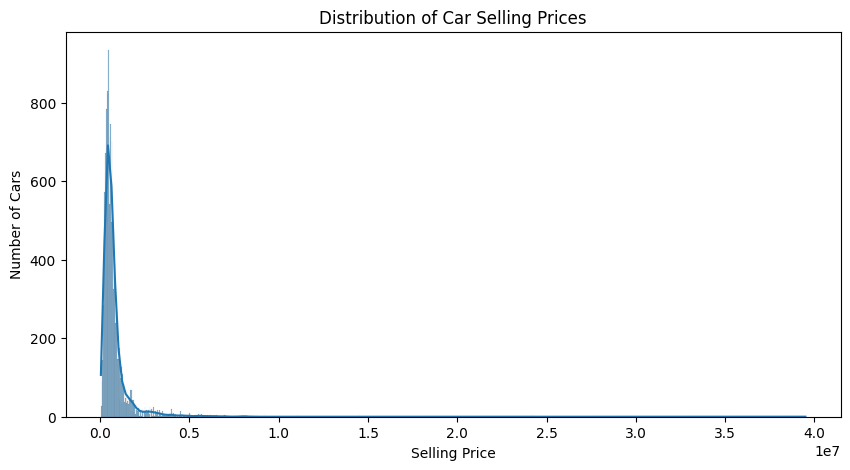

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(df["selling_price"], kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

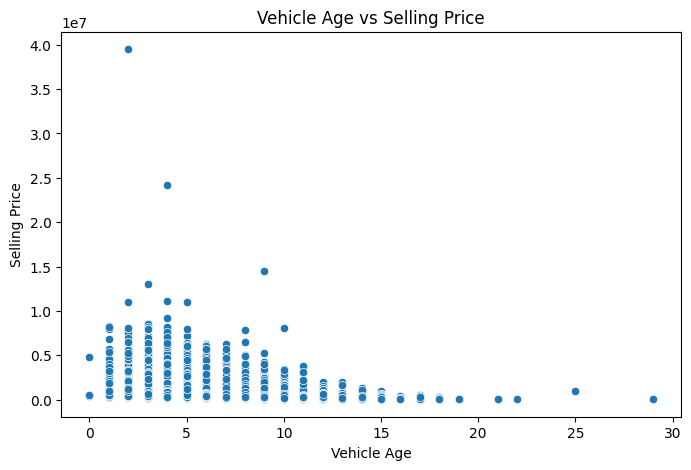

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="vehicle_age",
    y="selling_price"
)

plt.title("Vehicle Age vs Selling Price")
plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price")

plt.show()

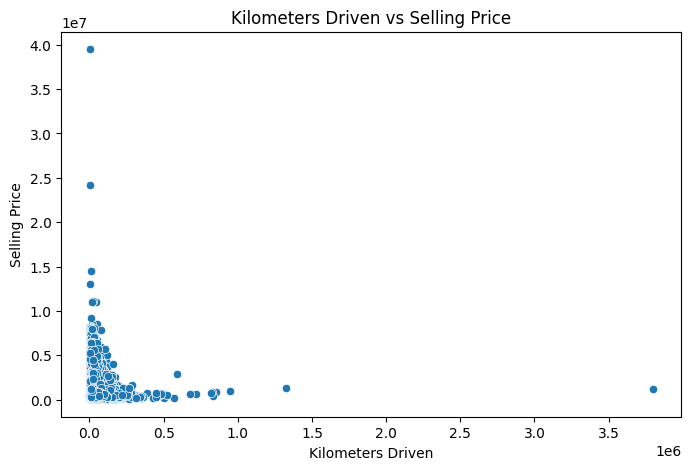

In [21]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price"
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.show()

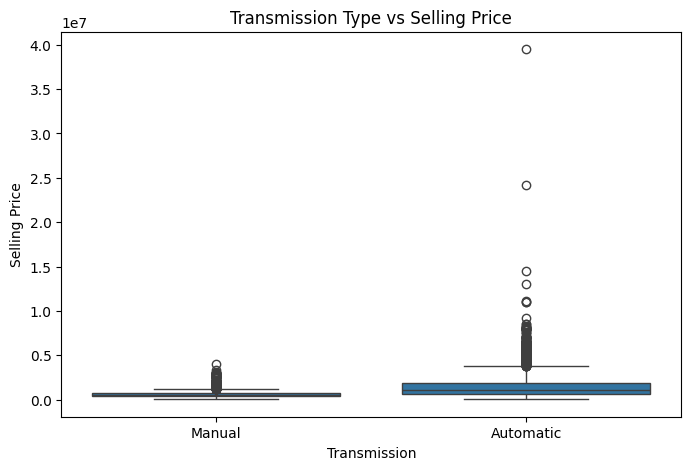

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="transmission_type",
    y="selling_price"
)

plt.title("Transmission Type vs Selling Price")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

plt.show()

In [23]:
X = df.drop("selling_price", axis=1)

y = df["selling_price"]

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [24]:
print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Input features:
['car_name', 'brand', 'model', 'min_cost_price', 'max_cost_price', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']

Target:
selling_price


In [30]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Numerical features:
['min_cost_price', 'max_cost_price', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 12244
Testing samples: 3062


In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [35]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


In [37]:
from sklearn.pipeline import Pipeline

In [38]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [39]:
pipeline.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [42]:
y_pred = pipeline.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [43]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 85213.93198310734


In [44]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 223986.51662889431


In [46]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)
print("R² Score (%):", r2 * 100)

R² Score: 0.9359749963421131
R² Score (%): 93.59749963421132


In [47]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(20)

,Actual Price,Predicted Price
0,245000,2.733025e+05
1,195000,2.833750e+05
2,1500000,1.692380e+06
3,345000,3.847200e+05
4,800000,6.425812e+05
5,925000,7.560800e+05
6,1150000,1.039983e+06
7,409000,3.889307e+05
8,475000,4.669150e+05
9,800000,7.065775e+05


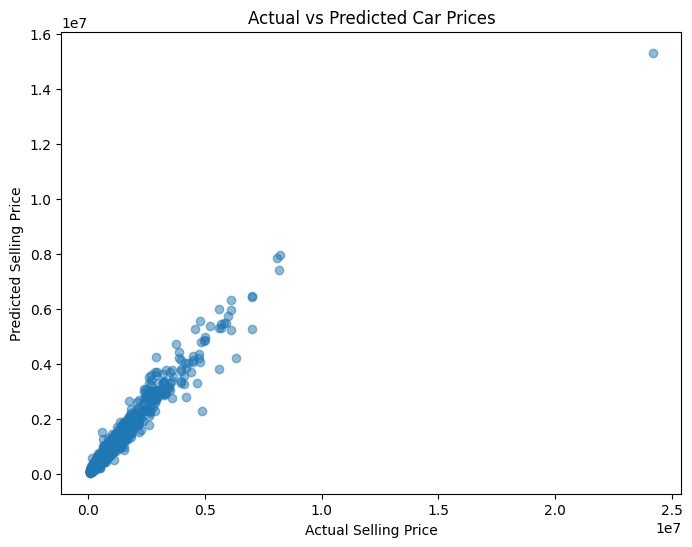

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

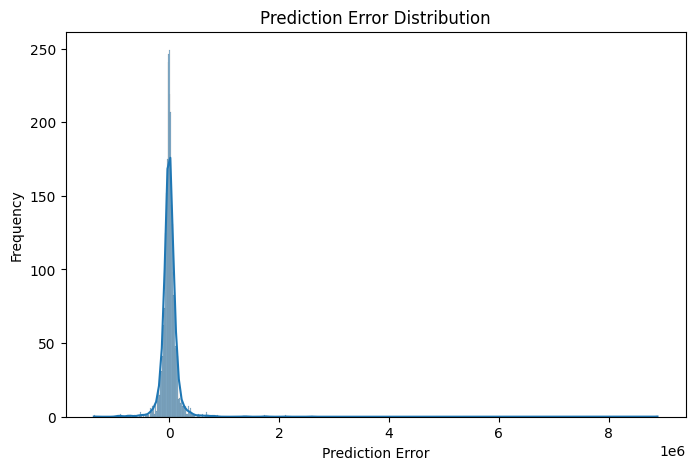

In [49]:
errors = y_test - y_pred

plt.figure(figsize=(8, 5))

sns.histplot(errors, kde=True)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [50]:
sample_car = X.iloc[[0]]

actual_price = y.iloc[0]

predicted_price = pipeline.predict(sample_car)[0]

print("Actual Price:", actual_price)
print("Predicted Price:", predicted_price)

Actual Price: 120000
Predicted Price: 178083.7380952381


In [51]:
sample_cars = X.iloc[:10]

predictions = pipeline.predict(sample_cars)

result = pd.DataFrame({
    "Actual Price": y.iloc[:10].values,
    "Predicted Price": predictions
})

result

,Actual Price,Predicted Price
0,120000,1.780837e+05
1,550000,5.301250e+05
2,215000,2.368350e+05
3,226000,2.259475e+05
4,570000,5.817250e+05
5,350000,3.202200e+05
6,315000,3.085850e+05
7,410000,4.236100e+05
8,1050000,1.028970e+06
9,511000,5.117450e+05


In [52]:
joblib.dump(
    pipeline,
    "car_price_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [53]:
loaded_model = joblib.load("car_price_model.pkl")

test_prediction = loaded_model.predict(X.iloc[[0]])

print("Prediction from saved model:", test_prediction[0])

Prediction from saved model: 178083.7380952381


In [54]:
import joblib

model = joblib.load("car_price_model.pkl")

In [56]:
print(X_train.shape)
print(X_test.shape)

(12244, 14)
(3062, 14)


In [57]:
pipeline.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [58]:
y_pred = pipeline.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 85213.93198310734
Root Mean Squared Error: 223986.51662889431
R² Score: 0.9359749963421131


In [60]:
import joblib

joblib.dump(pipeline, "car_price_model.pkl")

print("car_price_model.pkl saved successfully!")

car_price_model.pkl saved successfully!


In [68]:
from google.colab import files

files.download("car_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>